In [3]:
import pandas as pd

# 1. Buka CSV-nya dan kasih nama 'df' (singkatan dari DataFrame)
df = pd.read_csv('investments_VC.csv', encoding='unicode_escape')

# 2. Cek ringkasan datanya (kolom apa aja yang bolong)
df.info()

print("-" * 50)

# 3. Cek ada berapa startup yang sukses, mati, atau masih jalan
df['status'].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   permalink             49438 non-null  str    
 1   name                  49437 non-null  str    
 2   homepage_url          45989 non-null  str    
 3   category_list         45477 non-null  str    
 4    market               45470 non-null  str    
 5    funding_total_usd    49438 non-null  str    
 6   status                48124 non-null  str    
 7   country_code          44165 non-null  str    
 8   state_code            30161 non-null  str    
 9   region                44165 non-null  str    
 10  city                  43322 non-null  str    
 11  funding_rounds        49438 non-null  float64
 12  founded_at            38554 non-null  str    
 13  founded_month         38482 non-null  str    
 14  founded_quarter       38482 non-null  str    
 15  founded_year          38482 no

status
operating    41829
acquired      3692
closed        2603
Name: count, dtype: int64

In [4]:
# 1. Cukur habis spasi ghaib di nama kolom!
df.columns = df.columns.str.strip()

# 2. Buang kolom sampah yang nggak guna buat AI
kolom_sampah = ['permalink', 'homepage_url', 'state_code', 'region', 'city']
df_bersih = df.drop(columns=kolom_sampah)

# 3. Tendang startup yang kolom 'status'-nya kosong (NaN)
df_bersih = df_bersih.dropna(subset=['status'])

# Cek ukuran data kita sekarang setelah disapu bersih
print("Ukuran data setelah mandi:", df_bersih.shape)

# Intip 3 data teratas biar lega
df_bersih.head(3)

Ukuran data setelah mandi: (48124, 34)


,name,category_list,market,funding_total_usd,status,country_code,funding_rounds,founded_at,founded_month,founded_quarter,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,#waywire,|Entertainment|Politics|Social Media|News|,News,"17,50,000",acquired,USA,1.0,2012-06-01,2012-06,2012-Q2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,&TV Communications,|Games|,Games,"40,00,000",operating,USA,2.0,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,'Rock' Your Paper,|Publishing|Education|,Publishing,"40,000",operating,EST,1.0,2012-10-26,2012-10,2012-Q4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
# 1. Hapus tanda koma (,) dari semua angka uang
df_bersih['funding_total_usd'] = df_bersih['funding_total_usd'].str.replace(',', '', regex=True)

# 2. Hapus spasi kosong yang nggak sengaja ketik
df_bersih['funding_total_usd'] = df_bersih['funding_total_usd'].str.strip()

# 3. Ubah jadi tipe Angka (Numeric). Kalau ada tulisan aneh kayak " - ", paksa jadi NaN (kosong)
df_bersih['funding_total_usd'] = pd.to_numeric(df_bersih['funding_total_usd'], errors='coerce')

# 4. Intip hasilnya, sekalian cek rata-rata pendanaan!
print("Tipe data sekarang:", df_bersih['funding_total_usd'].dtype)
print("-" * 30)
df_bersih[['name', 'funding_total_usd']].head(5)

Tipe data sekarang: float64
------------------------------


,name,funding_total_usd
0,#waywire,1750000.0
1,&TV Communications,4000000.0
2,'Rock' Your Paper,40000.0
3,(In)Touch Network,1500000.0
4,-R- Ranch and Mine,60000.0


C:\Users\aqill\AppData\Local\Temp\ipykernel_4808\4010205969.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='status', data=df_bersih, palette='Set2', order=df_bersih['status'].value_counts().index)


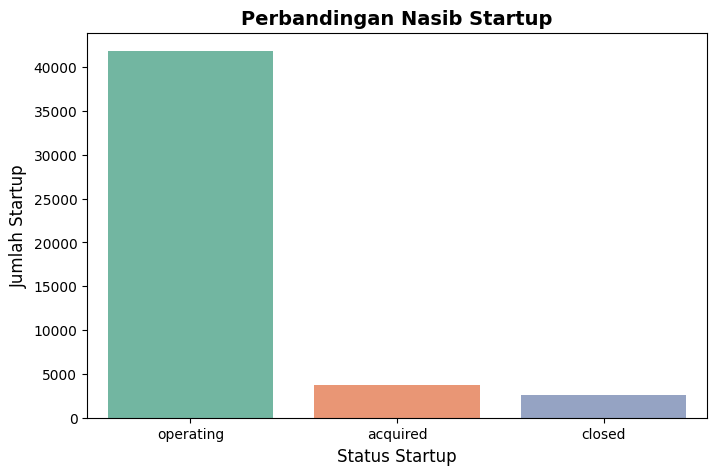

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Siapin kanvas gambarnya (ukuran 8x5)
plt.figure(figsize=(8, 5))

# 2. Gambar bar chart-nya berdasarkan kolom 'status'
# Urutin dari yang paling banyak ke paling dikit
sns.countplot(x='status', data=df_bersih, palette='Set2', order=df_bersih['status'].value_counts().index)

# 3. Kasih judul dan label biar cakep
plt.title('Perbandingan Nasib Startup', fontsize=14, fontweight='bold')
plt.xlabel('Status Startup', fontsize=12)
plt.ylabel('Jumlah Startup', fontsize=12)

# 4. Tunjukin ke layar!
plt.show()

In [7]:
# Simpan data yang udah mandi ini ke file CSV baru
df_bersih.to_csv('startup_cleaned.csv', index=False)

print("Data bersih berhasil di-save! Siap buat tempur besok! 💾🚀")

Data bersih berhasil di-save! Siap buat tempur besok! 💾🚀
